<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

Steam_Data_Final = pd.read_csv('/Users/vickywu/Documents/ECO 590 Data Analytics/assignment-1-SakurairoKaden/steam_games_final.csv')

In [16]:
Steam_Data_Final['release_year'] = pd.to_numeric(
    Steam_Data_Final['release_year'], errors='coerce')
Steam_Data_Final['positive_review_ratio'] = pd.to_numeric(
    Steam_Data_Final['positive_review_ratio'], errors='coerce')
Steam_Data_Final['Price'] = pd.to_numeric(
    Steam_Data_Final['Price'], errors='coerce')

In [17]:
yearly = (Steam_Data_Final
          .dropna(subset=['release_year', 'positive_review_ratio', 'Price'])
          .groupby('release_year')
          .agg(avg_ratio=('positive_review_ratio', 'mean'),
               avg_price=('Price',             'mean'))
          .reset_index())
yearly = yearly[yearly['release_year'] >= 2000]   # Starting from yhe 21 century 

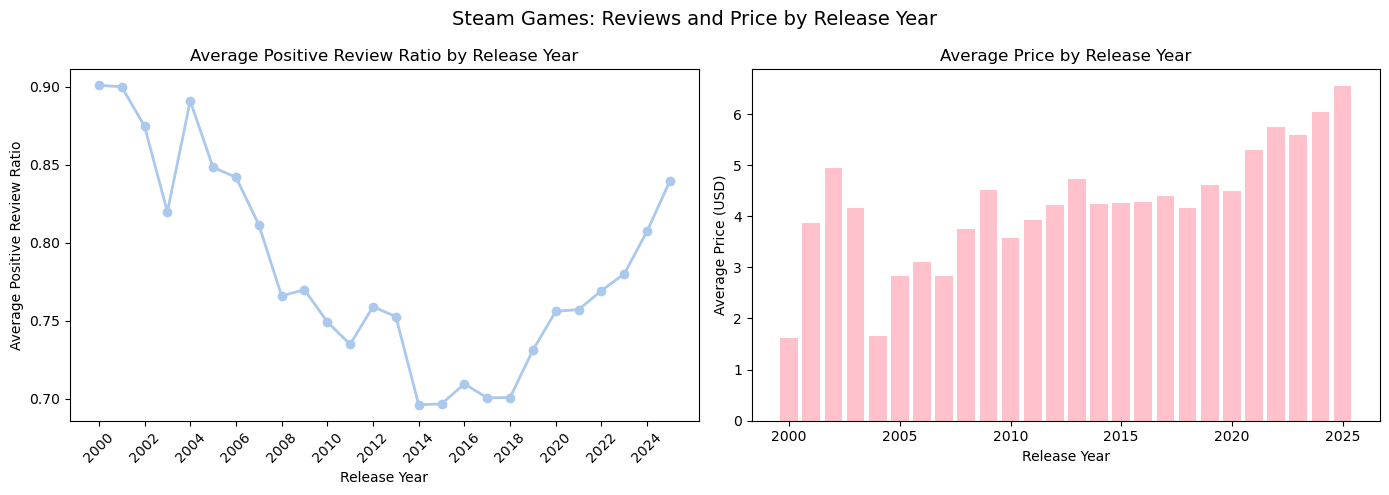

In [24]:
# ───────── Graphs 1 & 2 ────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Steam Games: Reviews and Price by Release Year', fontsize=14)

# ───────── Graph 1: Reviews Ratio by Release Year ───────────
ax1.plot(yearly['release_year'],
         yearly['avg_ratio'],
         marker = 'o',
         linewidth = 2,
         color = '#abc8ed')

ax1.set_title('Average Positive Review Ratio by Release Year')
ax1.set_xlabel('Release Year') 
ax1.set_ylabel('Average Positive Review Ratio')

ax1.set_xticks(yearly['release_year'] [::2]) ## Cleaning the X axis 
ax1.tick_params(axis='x', rotation=45)

# ───────── Graph 2: Price by Release Year ───────────
ax2.bar(yearly['release_year'], 
        yearly['avg_price'],
        color = '#ffc2cd')

ax2.set_title('Average Price by Release Year')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Average Price (USD)')

ax1.set_xticks(yearly['release_year'] [::2]) 
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

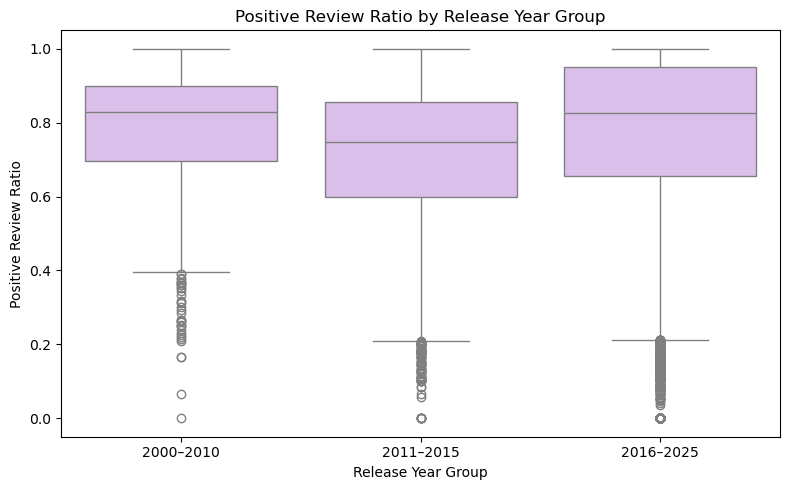

In [21]:
# ───────── Graph 3: Boxplot Price vs Reviews Ratio ───────────
Steam_Data_Final['year_group'] = pd.cut(Steam_Data_Final['release_year'],
    bins = [2000, 2010, 2015, 2025],
    labels = ['2000–2010', '2011–2015', '2016–2025'])

plt.figure(figsize = (8, 5))

sns.boxplot(data = Steam_Data_Final,
    x = 'year_group',
    y = 'positive_review_ratio',
    color = '#ddb8f2')

plt.title('Positive Review Ratio by Release Year Group')
plt.xlabel('Release Year Group')
plt.ylabel('Positive Review Ratio')

plt.tight_layout()
plt.show()

Graph 1 is the Line graph where I compare the average postive review to steam games that was realse over the the year of the 21 century. From what the graph has shown us, the new games tend to get more positive reviews than in the past.

Graph 2 is a bar graph where I compare the price to see if the increase in price might be why the player leaves a positive review or not. From what the bar graph have shown us it true that the prices of games have increase but so have the positive review shown in the line graph Graph 1 is the Line graph where I compare the average postive review to steam games that was realse over the the year of the 21 century. From what the graph has shown us, the new games tend to get more positive reviews than in the past.

And finally the last graph I used a box plot because it gives me a better visual to show how the distribution of positive review ratios across groups of years differs from one another, from the oldest game to the newer games. With newer games showing a slightly higher median, which suggests that more users enjoy the new games